In [5]:
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
df_ventas = pd.read_csv('../dataset/procesado/ventas_limpio.csv')

df_ventas.head()

,ordenID,productoID,UnitPrice,Quantity,NombreProducto,categoriaID,clienteID,fecha,NombreCategoria,TotalVenta,Mes,CategoriaVentas
0,10248,11,14.0,12,Queso Cabrales,4,VINET,1996-07-04,Dairy Products,168.0,1996-07,Media
1,10248,42,9.8,10,Singaporean Hokkien Fried Mee,5,VINET,1996-07-04,Grains/Cereals,98.0,1996-07,Baja
2,10248,72,34.8,5,Mozzarella di Giovanni,4,VINET,1996-07-04,Dairy Products,174.0,1996-07,Media
3,10249,14,18.6,9,Tofu,7,TOMSP,1996-07-05,Produce,167.4,1996-07,Media
4,10249,51,42.4,40,Manjimup Dried Apples,7,TOMSP,1996-07-05,Produce,1696.0,1996-07,Alta


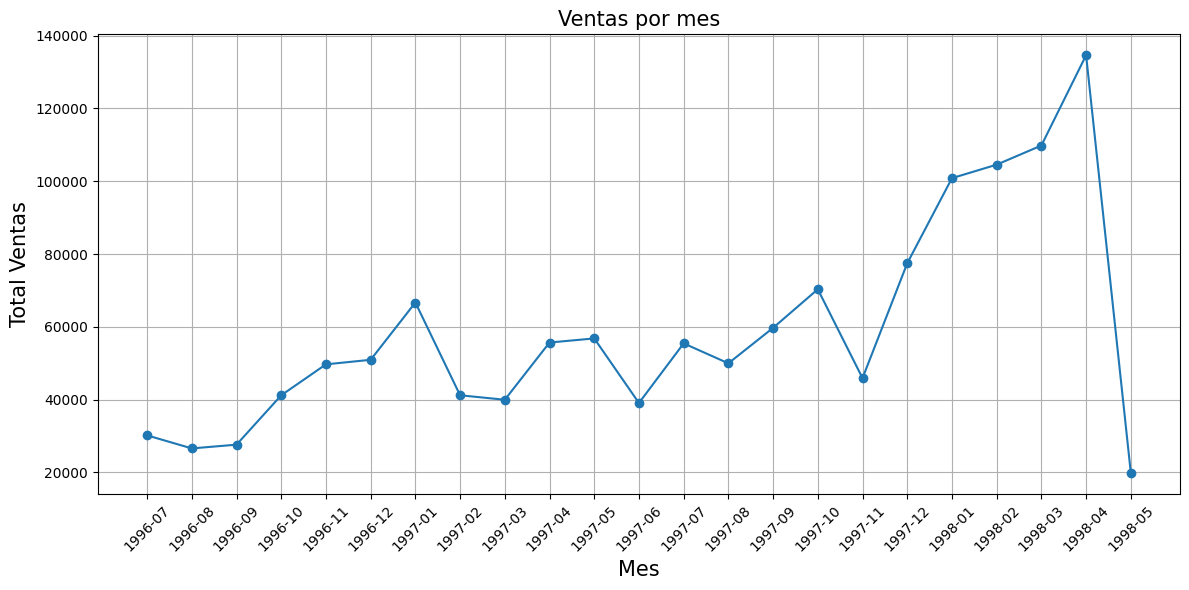

In [23]:
# Ventas por mes
ventas_mes = df_ventas.groupby('Mes', as_index = False).agg(
    TotalVenta = ('TotalVenta', 'sum')).sort_values('Mes')

plt.figure(figsize = (12, 6))
plt.plot(
    ventas_mes['Mes'], ventas_mes['TotalVenta'], marker = 'o'
)
plt.xticks(rotation = 45)
plt.title('Ventas por mes', fontsize = 15)
plt.xlabel('Mes', fontsize = 15)
plt.ylabel('Total Ventas', fontsize = 15)
plt.grid()
plt.tight_layout()
plt.show()

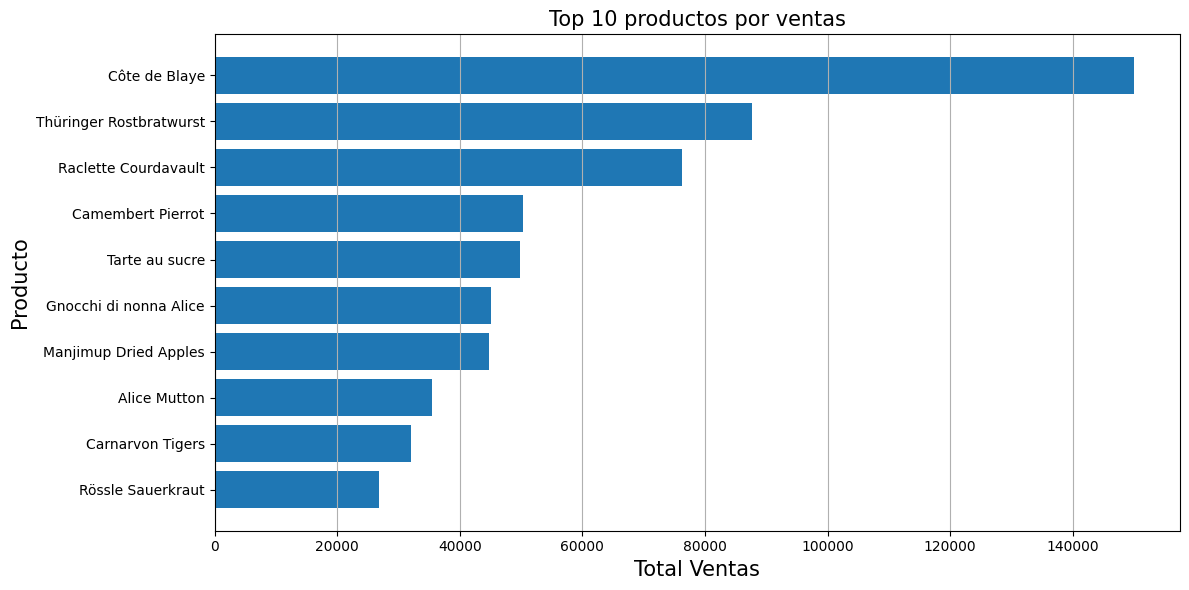

In [24]:
# Top 10 productos más vendidos
top_productos = df_ventas.groupby('NombreProducto', as_index = False).agg(
    TotalVenta = ('TotalVenta', 'sum')).sort_values('TotalVenta', ascending = False).head(10)

plt.figure(figsize = (12, 6))
plt.barh(
    top_productos['NombreProducto'], top_productos['TotalVenta']
)
plt.gca().invert_yaxis()
plt.title('Top 10 productos por ventas', fontsize = 15)
plt.xlabel('Total Ventas', fontsize = 15)
plt.ylabel('Producto', fontsize = 15)
plt.grid(axis = 'x')
plt.tight_layout()  
plt.show()

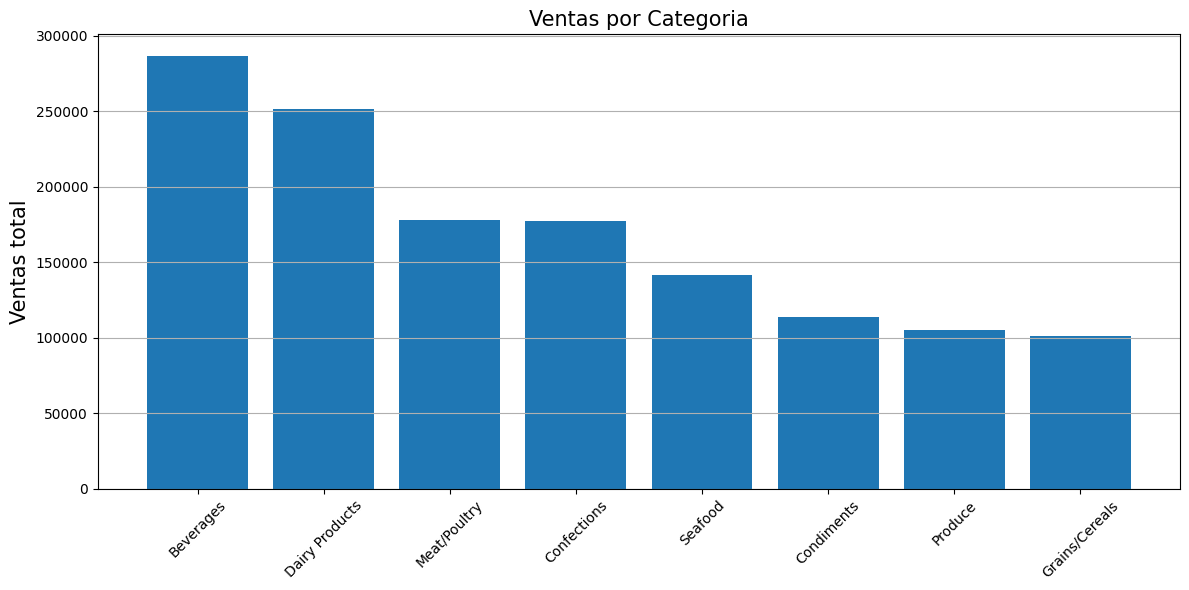

In [26]:
# Ventas por categoria
ventas_categoria = df_ventas.groupby('NombreCategoria', as_index = False).agg(
    TotalVenta = ('TotalVenta', 'sum')).sort_values('TotalVenta', ascending = False)

plt.figure(figsize = (12, 6))
plt.bar(
    ventas_categoria['NombreCategoria'], ventas_categoria['TotalVenta']
)
plt.xticks(rotation = 45)
plt.title('Ventas por Categoria', fontsize = 15)
plt.ylabel('Ventas total', fontsize = 15)
plt.grid(axis = 'y')
plt.tight_layout()
plt.show()

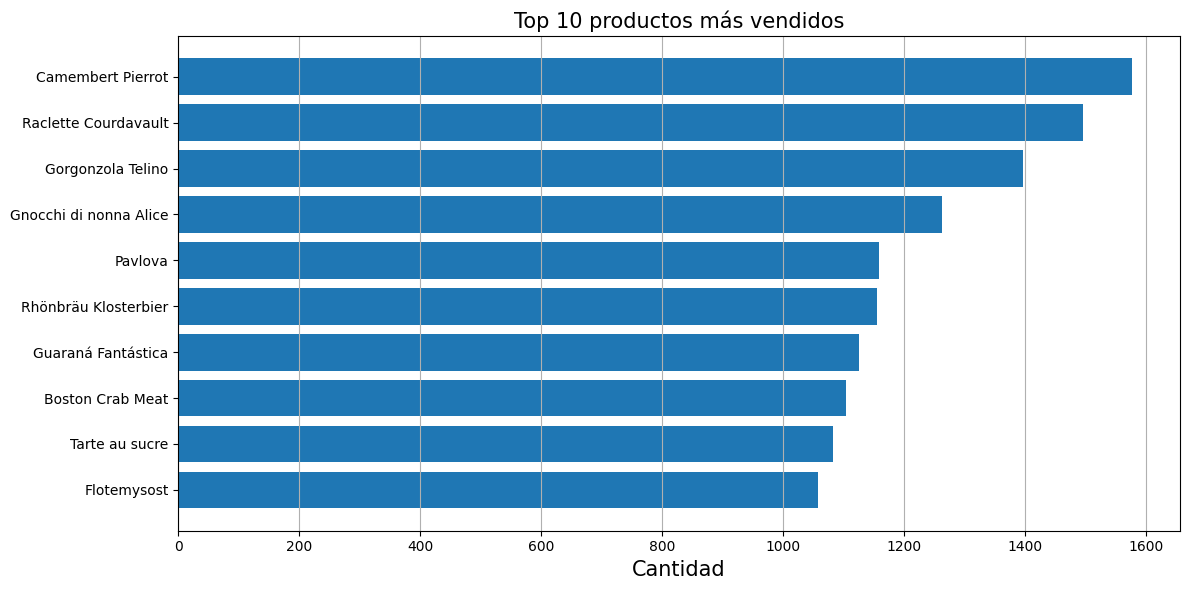

In [29]:
# Top 10 cantidad de productos vendidos
productos_cantidad_ventas = df_ventas.groupby('NombreProducto', as_index = False).agg(
    TotalCantidad = ('Quantity', 'sum')).sort_values('TotalCantidad', ascending = False).head(10)

plt.figure(figsize = (12, 6))
plt.barh(
    productos_cantidad_ventas['NombreProducto'], productos_cantidad_ventas['TotalCantidad']
)
plt.title('Top 10 productos más vendidos', fontsize = 15)
plt.gca().invert_yaxis()
plt.xlabel('Cantidad', fontsize = 15)
plt.grid(axis = 'x')
plt.tight_layout()
plt.show()

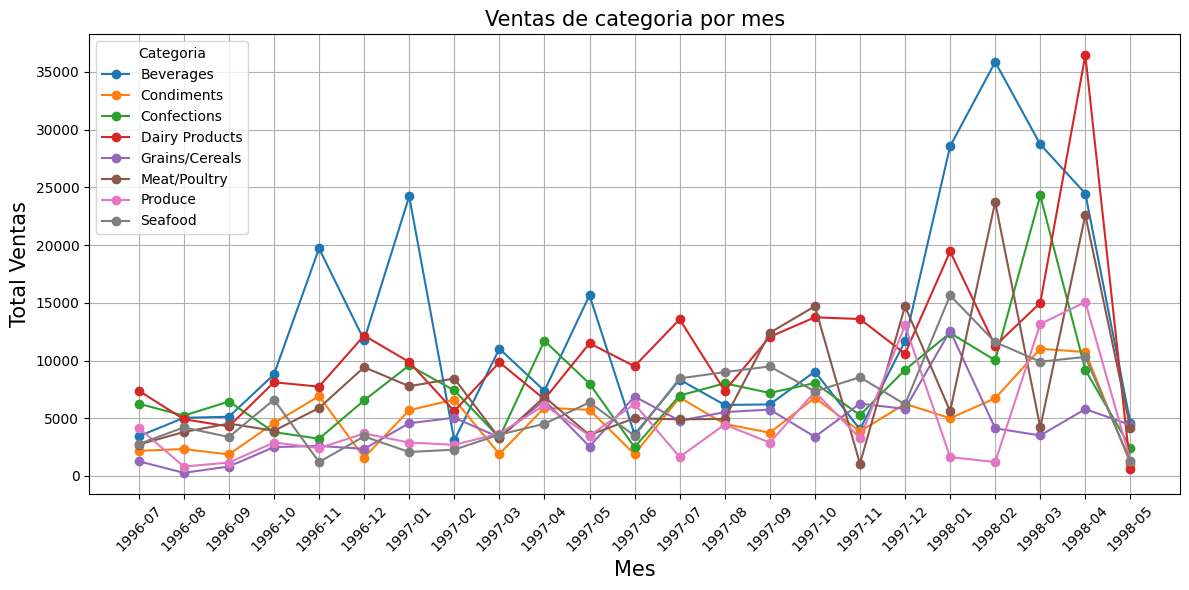

In [32]:
# Ventas de categoria por mes
ventas_categorias_mensual = df_ventas.groupby(['Mes', 'NombreCategoria'], as_index = False).agg(
    TotalVenta = ('TotalVenta', 'sum')
)
plt.figure(figsize = (12, 6))
for categoria in ventas_categorias_mensual['NombreCategoria'].unique():
    filtro_categorias = ventas_categorias_mensual[ventas_categorias_mensual['NombreCategoria'] == categoria]
    plt.plot(
        filtro_categorias['Mes'], filtro_categorias['TotalVenta'], marker = 'o', label = categoria
    )
plt.title('Ventas de categoria por mes', fontsize = 15)
plt.xlabel('Mes', fontsize = 15)
plt.ylabel('Total Ventas', fontsize = 15)
plt.legend(title = 'Categoria')
plt.xticks(rotation = 45)
plt.grid()
plt.tight_layout()
plt.show()

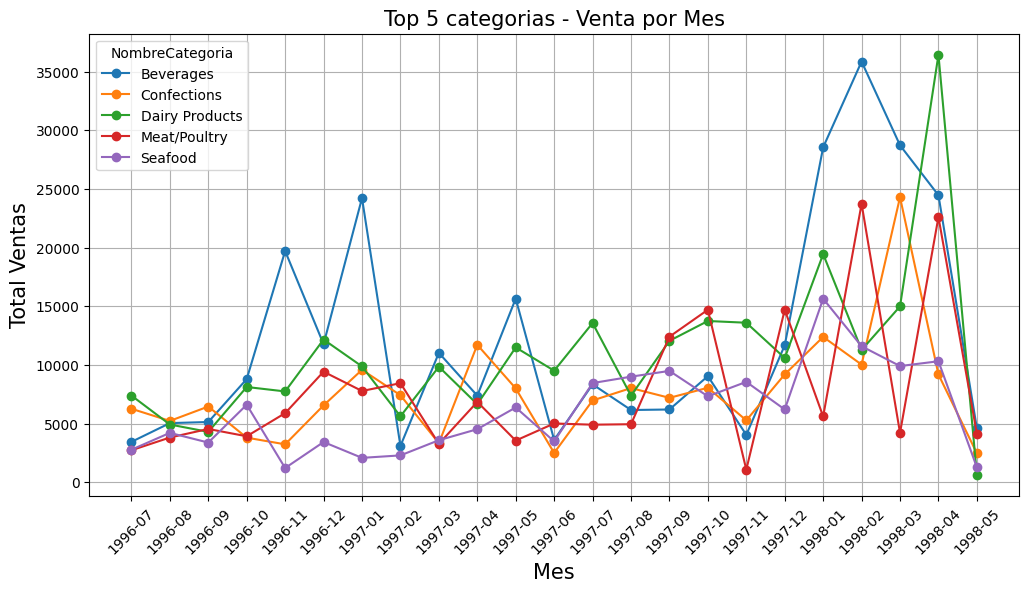

<class 'pandas.core.indexes.base.Index'>


In [44]:
# Top 5 categorias en el tiempo
top_categorias = df_ventas.groupby('NombreCategoria')['TotalVenta'].sum().nlargest(5).index

df_top = df_ventas[df_ventas['NombreCategoria'].isin(top_categorias)]

ventas = df_top.groupby(['Mes', 'NombreCategoria'])['TotalVenta'].sum().unstack()

ventas.plot(figsize = (12, 6), marker = 'o')

plt.title('Top 5 categorias - Venta por Mes', fontsize = 15)
plt.xlabel('Mes', fontsize = 15)
plt.ylabel('Total Ventas', fontsize = 15)
plt.xticks(rotation=45, ticks=range(len(ventas.index)), labels=ventas.index)
plt.grid()
plt.show()

print(type(top_categorias))